🖥️ Using device: cuda
Tesla P100-PCIE-16GB
Vocab sizes: Eng=20000, NL=20000

🔍 Running experiment: glove.100d


glove.100d Epoch 1: Val Loss=6.003, Acc=0.022


glove.100d Epoch 2: Val Loss=5.708, Acc=0.020


glove.100d Epoch 3: Val Loss=4.794, Acc=0.244


glove.100d Epoch 4: Val Loss=4.854, Acc=0.215


...

glove.100d Epoch 16: Val Loss=3.850, Acc=0.567


glove.100d Epoch 17: Val Loss=4.426, Acc=0.338


glove.100d Epoch 18: Val Loss=5.335, Acc=0.056


glove.100d Epoch 19: Val Loss=4.318, Acc=0.405


glove.100d Epoch 20: Val Loss=3.896, Acc=0.570


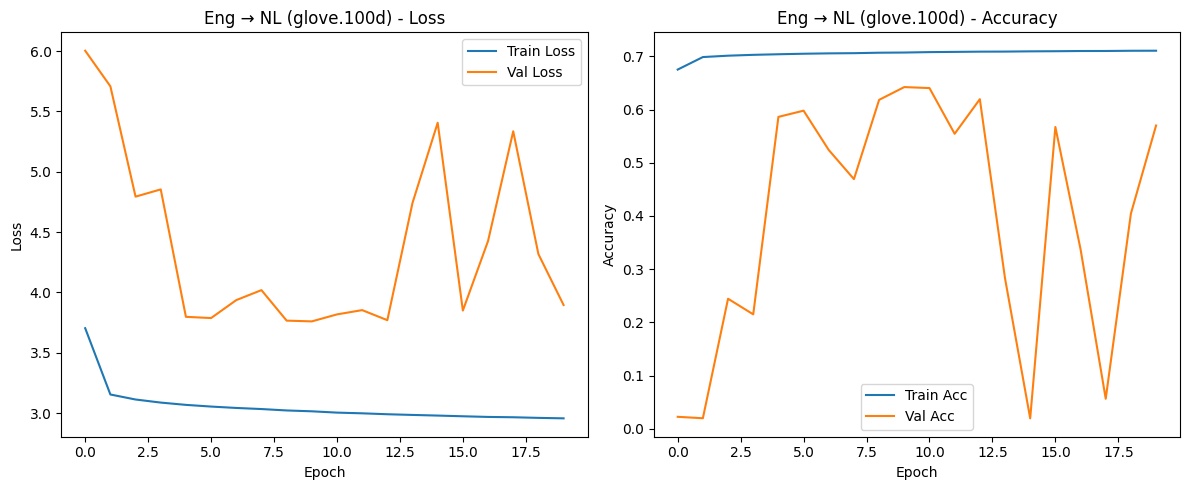

✅ glove.100d BLEU Score: 0.0126


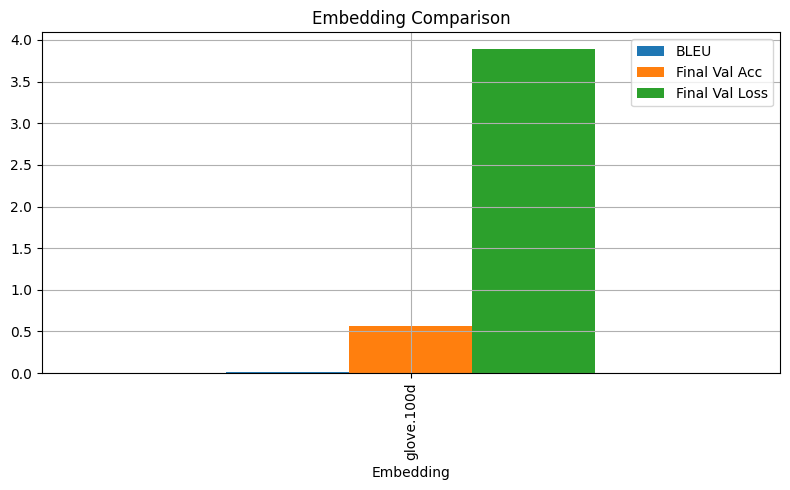

/kaggle/input/sample-data1/eng_sampled.csv
/kaggle/input/sample-data1/nl_sampled.csv
/kaggle/input/glove6b100dtxt/glove.6B.100d.txt


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)#%%
import os
import torch
import torch.nn as nn
import pandas as pd
import random
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt

# Enable faster convolution benchmarks for fixed input sizes
torch.backends.cudnn.benchmark = True

# Confirm GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# Tokenization and vocab
def tokenize(sentences):
    return [str(s).split() for s in sentences]

def build_vocab(token_lists, min_freq=2, max_size=20000):
    counter = Counter(tok for sent in token_lists for tok in sent)
    vocab = {'<PAD>':0, '<SOS>':1, '<EOS>':2, '<UNK>':3}
    sorted_toks = sorted((t for t in counter if counter[t] >= min_freq), key=lambda t: (-counter[t], t))
    for tok in sorted_toks:
        if len(vocab) >= max_size:
            break
        vocab[tok] = len(vocab)
    return vocab

def encode(tokens, vocab):
    return [vocab.get(t, vocab['<UNK>']) for t in tokens]

def pad_sequences(sequences, max_len, pad_value=0):
    return [seq[:max_len] + [pad_value]*(max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in sequences]

# Dataset class
class TranslationDataset(Dataset):
    def __init__(self, src, tgt, lengths):
        self.src = torch.tensor(src, dtype=torch.long)
        self.tgt = torch.tensor(tgt, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
    def __len__(self): return len(self.src)
    def __getitem__(self, idx): return self.src[idx], self.tgt[idx], self.lengths[idx]

# Pretrained Embedding Loader
def load_glove(path, vocab, dim):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = list(map(float, parts[1:]))
            if len(vec) != dim: continue
            embeddings[word] = torch.tensor(vec)
    matrix = torch.randn(len(vocab), dim) * 0.05
    matrix[vocab['<PAD>']] = torch.zeros(dim)
    for word, idx in vocab.items():
        if word in embeddings:
            matrix[idx] = embeddings[word]
    return matrix

# Models
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.3, pretrained=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        if pretrained is not None:
            self.embedding.weight.data.copy_(pretrained)
            self.embedding.weight.requires_grad = False
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
    def forward(self, src, lengths):
        emb = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        return hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.3, pretrained=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        if pretrained is not None:
            self.embedding.weight.data.copy_(pretrained)
            self.embedding.weight.requires_grad = False
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        emb = self.dropout(self.embedding(input))
        out, hidden = self.rnn(emb, hidden)
        return self.fc(out.squeeze(1)), hidden

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec, device):
        super().__init__()
        self.encoder = enc
        self.decoder = dec
        self.device = device
    def forward(self, src, lengths, tgt, tf_ratio=0.8):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc.out_features
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)
        hidden = self.encoder(src, lengths)
        input = tgt[:, 0]
        for t in range(1, tgt_len):
            out, hidden = self.decoder(input, hidden)
            outputs[:, t] = out
            input = tgt[:, t] if random.random() < tf_ratio else out.argmax(1)
        return outputs

# Training utilities
def label_smoothed_nll_loss(logits, target, epsilon=0.1):
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    nll = -log_probs.gather(dim=-1, index=target.unsqueeze(-1)).squeeze(-1)
    smooth = -log_probs.mean(dim=-1)
    return ((1 - epsilon) * nll + epsilon * smooth).mean()

def train(model, loader, optimizer, epoch, tf_ratio):
    model.train()
    total_loss, total_acc, count = 0, 0, 0
    for src, tgt, lengths in tqdm(loader, desc=f"Train {epoch}", leave=False):
        src, tgt, lengths = src.to(device), tgt.to(device), lengths.to(device)
        optimizer.zero_grad()
        out = model(src, lengths, tgt, tf_ratio)
        out = out[:, 1:].reshape(-1, out.size(-1))
        tgt_flat = tgt[:, 1:].reshape(-1)
        loss = label_smoothed_nll_loss(out, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        total_acc += (out.argmax(1) == tgt_flat).float().mean().item()
        count += 1
    return total_loss / count, total_acc / count

def evaluate(model, loader):
    model.eval()
    total_loss, total_acc, count = 0, 0, 0
    with torch.no_grad():
        for src, tgt, lengths in loader:
            src, tgt, lengths = src.to(device), tgt.to(device), lengths.to(device)
            out = model(src, lengths, tgt, tf_ratio=0.0)
            out = out[:, 1:].reshape(-1, out.size(-1))
            tgt_flat = tgt[:, 1:].reshape(-1)
            loss = label_smoothed_nll_loss(out, tgt_flat)
            total_loss += loss.item()
            total_acc += (out.argmax(1) == tgt_flat).float().mean().item()
            count += 1
    return total_loss / count, total_acc / count

def compute_bleu(model, loader, tgt_vocab):
    model.eval()
    refs, hyps = [], []
    sos, eos = tgt_vocab['<SOS>'], tgt_vocab['<EOS>']
    with torch.no_grad():
        for src, tgt, lengths in loader:
            src, tgt = src.to(device), tgt.to(device)
            out = model(src, lengths.to(device), tgt, tf_ratio=0.0)
            pred = out.argmax(-1).cpu().numpy()
            tgt = tgt.cpu().numpy()
            for r, h in zip(tgt, pred):
                r = [i for i in r if i not in (0, sos)]
                h = [i for i in h if i not in (0, sos)]
                if eos in r:
                    r = r[:r.index(eos)]
                if eos in h:
                    h = h[:h.index(eos)]
                refs.append([r])
                hyps.append(h)
    return corpus_bleu(refs, hyps)

# Main function
def main():
    eng_sample = pd.read_csv('/kaggle/input/sample-data1/eng_sampled.csv')
    nl_sample = pd.read_csv('/kaggle/input/sample-data1/nl_sampled.csv')

    eng_sample.dropna(subset=['sentence'], inplace=True)
    nl_sample.dropna(subset=['sentence'], inplace=True)

    eng_sample = eng_sample[eng_sample['sentence'].apply(lambda x: isinstance(x, str))]
    nl_sample = nl_sample[nl_sample['sentence'].apply(lambda x: isinstance(x, str))]

    eng_sample = eng_sample.reset_index(drop=True)
    nl_sample = nl_sample.reset_index(drop=True)

    indices = eng_sample.sample(frac=0.3, random_state=42).index
    eng = tokenize(eng_sample.loc[indices, 'sentence'])
    nl = [['<SOS>'] + s.split() + ['<EOS>'] for s in nl_sample.loc[indices, 'sentence']]

    eng_vocab = build_vocab(eng)
    nl_vocab = build_vocab(nl)
    print(f"Vocab sizes: Eng={len(eng_vocab)}, NL={len(nl_vocab)}")

    X = [encode(s, eng_vocab) for s in eng]
    Y = [encode(s, nl_vocab) for s in nl]

    max_len_x = min(80, max(len(x) for x in X))
    max_len_y = min(80, max(len(y) for y in Y))
    lengths = [min(len(x), max_len_x) for x in X]
    X = pad_sequences(X, max_len_x)
    Y = pad_sequences(Y, max_len_y)

    X_t, X_test, Y_t, Y_test, L_t, L_test = train_test_split(X, Y, lengths, test_size=0.2)
    X_tr, X_val, Y_tr, Y_val, L_tr, L_val = train_test_split(X_t, Y_t, L_t, test_size=0.1)

    train_loader = DataLoader(TranslationDataset(X_tr, Y_tr, L_tr), batch_size=64, shuffle=True)
    val_loader = DataLoader(TranslationDataset(X_val, Y_val, L_val), batch_size=64)

    experiments = [
        ("glove.100d", '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt', load_glove, 256)
    ]

    results = []

    for name, path, loader_fn, dim in experiments:
        print(f"\n🔍 Running experiment: {name}")
        eng_emb = loader_fn(path, eng_vocab, dim) if path else None
        nl_emb = loader_fn(path, nl_vocab, dim) if path else None

        encoder = Encoder(len(eng_vocab), 256,256, pretrained=eng_emb).to(device)
        decoder = Decoder(len(nl_vocab),  256,256, pretrained=nl_emb).to(device)
        model = Seq2Seq(encoder, decoder, device).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0004)

        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

        for epoch in range(20):
            train_loss, train_acc = train(model, train_loader, optimizer, epoch, tf_ratio=0.8)
            val_loss, val_acc = evaluate(model, val_loader)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            print(f"{name} Epoch {epoch+1}: Val Loss={val_loss:.3f}, Acc={val_acc:.3f}")

        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'Eng → NL ({name}) - Loss')

        plt.subplot(1,2,2)
        plt.plot(train_accs, label='Train Acc')
        plt.plot(val_accs, label='Val Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title(f'Eng → NL ({name}) - Accuracy')

        plt.tight_layout()
        plot_name = f"eng_to_nl_{name}_results.png"
        plt.savefig(plot_name, dpi=300, bbox_inches='tight')
        plt.show()

        bleu = compute_bleu(model, val_loader, nl_vocab)
        print(f"✅ {name} BLEU Score: {bleu:.4f}")

        results.append({
            'Embedding': name,
            'BLEU': bleu,
            'Final Val Loss': val_losses[-1],
            'Final Val Acc': val_accs[-1],
            'Plot File': plot_name
        })

    df = pd.DataFrame(results)
    df.plot(x='Embedding', y=['BLEU', 'Final Val Acc', 'Final Val Loss'], kind='bar', figsize=(8,5))
    plt.title("Embedding Comparison")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)#%%
import os
import torch
import torch.nn as nn
import pandas as pd
import random
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt

# Enable faster convolution benchmarks for fixed input sizes
torch.backends.cudnn.benchmark = True

# Confirm GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# Tokenization and vocab
def tokenize(sentences):
    return [str(s).split() for s in sentences]

def build_vocab(token_lists, min_freq=2, max_size=20000):
    counter = Counter(tok for sent in token_lists for tok in sent)
    vocab = {'<PAD>':0, '<SOS>':1, '<EOS>':2, '<UNK>':3}
    sorted_toks = sorted((t for t in counter if counter[t] >= min_freq), key=lambda t: (-counter[t], t))
    for tok in sorted_toks:
        #if len(vocab) >= max_size:
        #    break
        vocab[tok] = len(vocab)
    return vocab

def encode(tokens, vocab):
    return [vocab.get(t, vocab['<UNK>']) for t in tokens]

def pad_sequences(sequences, max_len, pad_value=0):
    return [seq[:max_len] + [pad_value]*(max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in sequences]

# Dataset class
class TranslationDataset(Dataset):
    def __init__(self, src, tgt, lengths):
        self.src = torch.tensor(src, dtype=torch.long)
        self.tgt = torch.tensor(tgt, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
    def __len__(self): return len(self.src)
    def __getitem__(self, idx): return self.src[idx], self.tgt[idx], self.lengths[idx]

# Pretrained Embedding Loader
def load_glove(path, vocab, dim):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = list(map(float, parts[1:]))
            if len(vec) != dim: continue
            embeddings[word] = torch.tensor(vec)
    matrix = torch.randn(len(vocab), dim) * 0.05
    matrix[vocab['<PAD>']] = torch.zeros(dim)
    for word, idx in vocab.items():
        if word in embeddings:
            matrix[idx] = embeddings[word]
    return matrix

# Models
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.3, pretrained=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        if pretrained is not None:
            self.embedding.weight.data.copy_(pretrained)
            self.embedding.weight.requires_grad = False
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
    def forward(self, src, lengths):
        emb = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.rnn(packed)
        return hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.3, pretrained=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        if pretrained is not None:
            self.embedding.weight.data.copy_(pretrained)
            self.embedding.weight.requires_grad = False
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        emb = self.dropout(self.embedding(input))
        out, hidden = self.rnn(emb, hidden)
        return self.fc(out.squeeze(1)), hidden

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec, device):
        super().__init__()
        self.encoder = enc
        self.decoder = dec
        self.device = device
    def forward(self, src, lengths, tgt, tf_ratio=0.8):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc.out_features
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)
        hidden = self.encoder(src, lengths)
        input = tgt[:, 0]
        for t in range(1, tgt_len):
            out, hidden = self.decoder(input, hidden)
            outputs[:, t] = out
            input = tgt[:, t] if random.random() < tf_ratio else out.argmax(1)
        return outputs

# Training utilities
def label_smoothed_nll_loss(logits, target, epsilon=0.1):
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    nll = -log_probs.gather(dim=-1, index=target.unsqueeze(-1)).squeeze(-1)
    smooth = -log_probs.mean(dim=-1)
    return ((1 - epsilon) * nll + epsilon * smooth).mean()

def train(model, loader, optimizer, epoch, tf_ratio):
    model.train()
    total_loss, total_acc, count = 0, 0, 0
    for src, tgt, lengths in tqdm(loader, desc=f"Train {epoch}", leave=False):
        src, tgt, lengths = src.to(device), tgt.to(device), lengths.to(device)
        optimizer.zero_grad()
        out = model(src, lengths, tgt, tf_ratio)
        out = out[:, 1:].reshape(-1, out.size(-1))
        tgt_flat = tgt[:, 1:].reshape(-1)
        loss = label_smoothed_nll_loss(out, tgt_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        total_acc += (out.argmax(1) == tgt_flat).float().mean().item()
        count += 1
    return total_loss / count, total_acc / count

def evaluate(model, loader):
    model.eval()
    total_loss, total_acc, count = 0, 0, 0
    with torch.no_grad():
        for src, tgt, lengths in loader:
            src, tgt, lengths = src.to(device), tgt.to(device), lengths.to(device)
            out = model(src, lengths, tgt, tf_ratio=0.0)
            out = out[:, 1:].reshape(-1, out.size(-1))
            tgt_flat = tgt[:, 1:].reshape(-1)
            loss = label_smoothed_nll_loss(out, tgt_flat)
            total_loss += loss.item()
            total_acc += (out.argmax(1) == tgt_flat).float().mean().item()
            count += 1
    return total_loss / count, total_acc / count

def compute_bleu(model, loader, tgt_vocab):
    model.eval()
    refs, hyps = [], []
    sos, eos = tgt_vocab['<SOS>'], tgt_vocab['<EOS>']
    with torch.no_grad():
        for src, tgt, lengths in loader:
            src, tgt = src.to(device), tgt.to(device)
            out = model(src, lengths.to(device), tgt, tf_ratio=0.0)
            pred = out.argmax(-1).cpu().numpy()
            tgt = tgt.cpu().numpy()
            for r, h in zip(tgt, pred):
                r = [i for i in r if i not in (0, sos)]
                h = [i for i in h if i not in (0, sos)]
                if eos in r:
                    r = r[:r.index(eos)]
                if eos in h:
                    h = h[:h.index(eos)]
                refs.append([r])
                hyps.append(h)
    return corpus_bleu(refs, hyps)

# Main function
def main():
    eng_sample = pd.read_csv('/kaggle/input/sample-data1/eng_sampled.csv')
    nl_sample = pd.read_csv('/kaggle/input/sample-data1/nl_sampled.csv')

    eng_sample.dropna(subset=['sentence'], inplace=True)
    nl_sample.dropna(subset=['sentence'], inplace=True)

    eng_sample = eng_sample[eng_sample['sentence'].apply(lambda x: isinstance(x, str))]
    nl_sample = nl_sample[nl_sample['sentence'].apply(lambda x: isinstance(x, str))]

    eng_sample = eng_sample.reset_index(drop=True)
    nl_sample = nl_sample.reset_index(drop=True)

    indices = eng_sample.sample(frac=0.3, random_state=42).index
    eng = tokenize(eng_sample.loc[indices, 'sentence'])
    nl = [['<SOS>'] + s.split() + ['<EOS>'] for s in nl_sample.loc[indices, 'sentence']]

    eng_vocab = build_vocab(eng)
    nl_vocab = build_vocab(nl)
    print(f"Vocab sizes: Eng={len(eng_vocab)}, NL={len(nl_vocab)}")

    X = [encode(s, eng_vocab) for s in eng]
    Y = [encode(s, nl_vocab) for s in nl]

    max_len_x = min(80, max(len(x) for x in X))
    max_len_y = min(80, max(len(y) for y in Y))
    lengths = [min(len(x), max_len_x) for x in X]
    X = pad_sequences(X, max_len_x)
    Y = pad_sequences(Y, max_len_y)

    X_t, X_test, Y_t, Y_test, L_t, L_test = train_test_split(X, Y, lengths, test_size=0.2)
    X_tr, X_val, Y_tr, Y_val, L_tr, L_val = train_test_split(X_t, Y_t, L_t, test_size=0.1)

    train_loader = DataLoader(TranslationDataset(X_tr, Y_tr, L_tr), batch_size=64, shuffle=True)
    val_loader = DataLoader(TranslationDataset(X_val, Y_val, L_val), batch_size=64)

    experiments = [
        ("glove.100d", '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt', load_glove, 100)
    ]

    results = []

    for name, path, loader_fn, dim in experiments:
        print(f"\n🔍 Running experiment: {name}")
        eng_emb = loader_fn(path, eng_vocab, dim) if path else None
        nl_emb = loader_fn(path, nl_vocab, dim) if path else None
        print(eng_vocab)

        encoder = Encoder(len(eng_vocab), dim, 128, pretrained=eng_emb).to(device)
        decoder = Decoder(len(nl_vocab), dim, 128, pretrained=nl_emb).to(device)
        model = Seq2Seq(encoder, decoder, device).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0004)

        train_losses, val_losses = [], []
        train_accs, val_accs = [], []

        for epoch in range(20):
            train_loss, train_acc = train(model, train_loader, optimizer, epoch, tf_ratio=0.8)
            val_loss, val_acc = evaluate(model, val_loader)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            print(f"{name} Epoch {epoch+1}: Val Loss={val_loss:.3f}, Acc={val_acc:.3f}")

        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'Eng → NL ({name}) - Loss')

        plt.subplot(1,2,2)
        plt.plot(train_accs, label='Train Acc')
        plt.plot(val_accs, label='Val Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title(f'Eng → NL ({name}) - Accuracy')

        plt.tight_layout()
        plot_name = f"eng_to_nl_{name}_results.png"
        plt.savefig(plot_name, dpi=300, bbox_inches='tight')
        plt.show()

        bleu = compute_bleu(model, val_loader, nl_vocab)
        print(f"✅ {name} BLEU Score: {bleu:.4f}")

        results.append({
            'Embedding': name,
            'BLEU': bleu,
            'Final Val Loss': val_losses[-1],
            'Final Val Acc': val_accs[-1],
            'Plot File': plot_name
        })

    df = pd.DataFrame(results)
    df.plot(x='Embedding', y=['BLEU', 'Final Val Acc', 'Final Val Loss'], kind='bar', figsize=(8,5))
    plt.title("Embedding Comparison")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session